# 02 Define Precise Pixel Mask With Napari

            Alternative to `02_define_mask_pixel.ipynb`. Opens the raw hologram in
            Napari with an editable labels layer. Paint label `1` over pixels to
            mask, then save `mask_pixel` and `mask_pixel_c` back into the HDF5 file.

In [1]:
import os, sys
from os.path import join
import importlib.util
import subprocess


def find_basefolder(start=None):
    folder = os.path.abspath(start or os.getcwd())
    for _ in range(8):
        if os.path.isdir(join(folder, "library")) and os.path.isdir(join(folder, "raw")):
            return folder
        parent = os.path.dirname(folder)
        if parent == folder:
            break
        folder = parent
    raise FileNotFoundError("Could not find beamtime root containing library/ and raw/.")


BASEFOLDER = find_basefolder()
print("Beamtime root:", BASEFOLDER)

# Keep Napari's generated cache/config inside this beamtime folder.
os.environ.setdefault("NUMBA_DISABLE_JIT", "1")
os.environ.setdefault("XDG_CACHE_HOME", join(BASEFOLDER, "processed", "napari_cache"))
os.environ.setdefault("XDG_CONFIG_HOME", join(BASEFOLDER, "processed", "napari_config"))

%gui qt

import h5py
import numpy as np
import matplotlib.pyplot as plt

print("Notebook kernel Python:", sys.executable)
if importlib.util.find_spec("napari") is None:
    print("Napari is missing in this notebook kernel. Installing napari[all] here...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "napari[all]"])

try:
    import napari
    from napari.utils.colormaps import DirectLabelColormap
except ImportError as exc:
    if "pydantic" not in str(exc).lower():
        raise
    print("Repairing pydantic for this notebook kernel, then retrying Napari import...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--force-reinstall", "pydantic>=2.12,<3"])
    import napari
    from napari.utils.colormaps import DirectLabelColormap

sys.path.append(join(BASEFOLDER, "library"))
import fth_phase_workflow as wf
from interactive import cimshow

try:
    import cupy as cp
    import cupyx as cpx
    import CCI_core_cupy as cci
    GPU = True
    print("GPU available")
except Exception:
    import CCI_core as cci
    GPU = False
    print("GPU unavailable")

Beamtime root: /Users/riccardo/Desktop/HZB/Beamtimes/2606_BESSY_UE51PGM
Notebook kernel Python: /Users/riccardo/anaconda3/envs/myenv/bin/python


  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/riccardo/anaconda3/envs/myenv/lib/python3.14/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/riccardo/anaconda3/envs/myenv/lib/python3.14/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/Users/riccardo/anaconda3/envs/myenv/lib/python3.14/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/Users/riccardo/anaconda3/envs/myenv/lib/python3.14/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/Users/riccardo/anaconda3/envs/myenv/lib/python3.14/asyncio/base_events.py", line 677, in run_forever
    self._run_once()
  File "/Users/riccardo/anaconda3/envs/myenv/lib/python3.14/asyncio/base_events.py", line 2057, in _run_once
    handle._run()
  File "/Users/riccardo/anaconda

GPU unavailable
GPU unavailable


## Load data

In [2]:
DATA_H5 = join(BASEFOLDER, "processed", "Logs", "data_recon_ImId_1269_rb.hdf5")
data = wf.load_data_dict(DATA_H5)
positive_label = data["positive_label"]
raw_image = np.asarray(data["holo"][positive_label]["image"])
mask_pixel = np.asarray(data.get("mask_pixel", np.zeros(raw_image.shape)), dtype=np.uint8)

print("Loaded:", DATA_H5)
print("Raw image shape:", raw_image.shape)
print("Existing masked pixels:", int(mask_pixel.sum()))

Loaded: /Users/riccardo/Desktop/HZB/Beamtimes/2606_BESSY_UE51PGM/processed/Logs/data_recon_ImId_1269_rb.hdf5
Raw image shape: (1300, 1340)
Existing masked pixels: 0


## Paint mask in Napari

In [ ]:
# Paint on the "mask_pixel" labels layer.
# In Napari, select the mask_pixel layer, choose label 1, and use the paintbrush,
# fill bucket, or polygon tool. Label 0 erases.
from qtpy.QtWidgets import QApplication

app = QApplication.instance() or QApplication([])
try:
    viewer.close()
except NameError:
    pass

viewer = napari.Viewer(title=f"mask_pixel ImId {int(data['holo'][positive_label]['id']):04d}")
viewer.add_image(
    raw_image,
    name=f"{positive_label} raw hologram",
    colormap="viridis",
    contrast_limits=np.nanpercentile(raw_image, (0, 100)),
)
mask_layer = viewer.add_labels(
    mask_pixel.astype(np.uint8),
    name="mask_pixel",
    opacity=0.6,
    colormap=DirectLabelColormap(
        color_dict={
            0: np.array([0.0, 0.0, 0.0, 0.0]),
            1: np.array([1.0, 0.0, 0.0, 1.0]),
            None: np.array([1.0, 0.0, 0.0, 1.0]),
        }
    ),
)
mask_layer.selected_label = 1
mask_layer.brush_size = 5
viewer.layers.selection.active = mask_layer
viewer.dims.ndisplay = 2
viewer.window.show()
viewer.window._qt_window.raise_()
viewer.window._qt_window.activateWindow()
app.processEvents()

print("Napari viewer opened. If it is not visible, check behind VS Code or use Mission Control.")
print("Paint red label 1 in the 'mask_pixel' layer, then run the save cell below.")

Napari viewer opened. If it is not visible, check behind VS Code or use Mission Control.
Paint red label 1 in the 'mask_pixel' layer, then run the save cell below.


## Save mask_pixel

/Users/riccardo/anaconda3/envs/myenv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: /Users/riccardo/Desktop/HZB/Beamtimes/2606_BESSY_UE51PGM/processed/masks/mask_pixel_ImId1269.png is a low contrast image
  return func(*args, **kwargs)


Updated mask_pixel in: /Users/riccardo/Desktop/HZB/Beamtimes/2606_BESSY_UE51PGM/processed/Logs/data_recon_ImId_1269_rb.hdf5
Saved mask PNG: /Users/riccardo/Desktop/HZB/Beamtimes/2606_BESSY_UE51PGM/processed/masks/mask_pixel_ImId1269.png
Masked pixels: 0


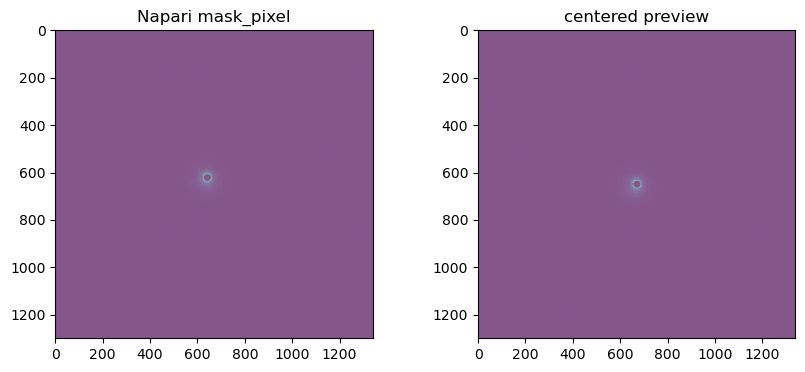

In [4]:
# Run this after you finish painting in Napari.
mask_pixel = (np.asarray(mask_layer.data) > 0).astype(np.uint8)
mask_pixel_c = wf.center_image(mask_pixel, data["center"], cci)
mask_pixel_c = (mask_pixel_c > 0.5).astype(np.uint8)
polygon_coordinates = []
mask_pixel_png = wf.save_binary_mask_png(BASEFOLDER, "mask_pixel", data["holo"][positive_label]["id"], mask_pixel)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(raw_image, cmap="viridis")
ax[0].imshow(mask_pixel, alpha=0.35, cmap="Reds")
ax[0].set_title("Napari mask_pixel")
ax[1].imshow(data["holo"][positive_label]["image_c"], cmap="viridis")
ax[1].imshow(mask_pixel_c, alpha=0.35, cmap="Reds")
ax[1].set_title("centered preview")
for key in [
    "dark_id_im",
    "dark_id_topo",
    "im_id",
    "topo_id",
    "fth_hologram",
    "fth_hologram_unmasked",
    "fth_png_title",
    "fth_recon",
    "fth_recon_unmasked",
    "mask_pixel_smooth",
    "mask_multiplier",
    "sum_c",
    "diff_c",
    "mask_pixel_c",
    "mask_pixel_c_png",
    "prop_dist",
    "phase",
    "dx",
    "dy",
    "focus_operation",
    "roi",
    "recon_cdi",
    "recon_topo_cdi",
    "phase_retrieval_png",
    "roi_cdi",
    "retrieved_type",
    "phase_cdi",
    "prop_dist_cdi",
    "dx_cdi",
    "dy_cdi",
    "focus_mode_cdi",
    "roi_crop",
    "mask_bs_cdi",
]:
    data.pop(key, None)
data.update(
    {
        "mask_pixel": mask_pixel,
        "polygon_coordinates": polygon_coordinates,
        "mask_pixel_source": "napari",
        "mask_pixel_png": mask_pixel_png,
    }
)
wf.save_data_dict(data, DATA_H5, overwrite=True)
print("Updated mask_pixel in:", DATA_H5)
print("Saved mask PNG:", mask_pixel_png)
print("Masked pixels:", int(mask_pixel.sum()))

In [5]:
# Workflow summary
_summary_data = data if "data" in globals() and isinstance(data, dict) else {}
_summary_h5 = globals().get("DATA_H5", _summary_data.get("data_file", "n/a"))
_summary_holo = _summary_data.get("holo", {})
_summary_pos = _summary_data.get("positive_label", globals().get("positive_label", None))
_summary_ref = _summary_data.get("reference_label", globals().get("reference_label", None))
_summary_im = _summary_holo.get(_summary_pos, {}).get("id", globals().get("im_id", "n/a"))
_summary_topo = _summary_holo.get(_summary_ref, {}).get("id", globals().get("topo_id", "n/a"))
print("im_id:", _summary_im)
print("topo_id:", _summary_topo)
print("HDF5:", _summary_h5)

im_id: 1269
topo_id: 1266
HDF5: /Users/riccardo/Desktop/HZB/Beamtimes/2606_BESSY_UE51PGM/processed/Logs/data_recon_ImId_1269_rb.hdf5
